# 03 — Simple models: Linear Regression & Decision Tree

**Goal:** two easy supervised baselines that use the 24 features to predict the **next-day log-return**, then reconstruct the price. Hyperparameters are chosen with **time-series cross-validation** (never shuffled). We compare the two on the same test set.

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
# make the models/ folder importable whether the notebook runs from models/ or the repo root
HERE = os.getcwd()
MODELS_DIR = HERE if os.path.exists(os.path.join(HERE, "utils.py")) else os.path.join(HERE, "models")
sys.path.insert(0, MODELS_DIR)
import utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

## 1. Data, split, feature matrix
`X` = the 24 engineered + exogenous + calendar columns; target = next-day log-return. We fit on train+validation and test on the held-out test set; CV folds come from `TimeSeriesSplit` (respects time order).

In [2]:
df = utils.load_modeling_frame()
train, val, test = utils.chrono_split(df)
trainval = pd.concat([train, val])
Xtr, ytr = trainval[utils.FEATURE_COLUMNS], trainval[utils.TARGET]
Xte = test[utils.FEATURE_COLUMNS]
actual = utils.actual_test_price(test)
tscv = TimeSeriesSplit(n_splits=5)

## 2. Linear Regression
Linear Regression has no real hyperparameters, so we standardize the features and fit. (A regularized variant like Ridge would be where you'd grid-search an `alpha`.)

In [3]:
lin = Pipeline([("scale", StandardScaler()), ("lr", LinearRegression())])
lin.fit(Xtr, ytr)
lin_pred = utils.reconstruct_price(test["y"], lin.predict(Xte))
lin_m = utils.evaluate(actual, lin_pred)
print("LinearRegression:", {k: round(v, 4) for k, v in lin_m.items()})
utils.save_predictions("linear_regression", test, lin_pred);

LinearRegression: {'MAE': 1.7158, 'RMSE': 2.4051, 'MAPE': 1.2944, 'R2': 0.99}


## 3. Decision Tree + GridSearchCV (TimeSeriesSplit)
Grid-search tree depth and leaf size with time-series CV, scoring by RMSE.

In [4]:
grid = {"max_depth": [2, 3, 4, 6, 8], "min_samples_leaf": [10, 20, 50, 100]}
dt = GridSearchCV(DecisionTreeRegressor(random_state=utils.SEED), grid,
                  cv=tscv, scoring="neg_root_mean_squared_error")
dt.fit(Xtr, ytr)
print("best params:", dt.best_params_)
dt_pred = utils.reconstruct_price(test["y"], dt.predict(Xte))
dt_m = utils.evaluate(actual, dt_pred)
print("DecisionTree:", {k: round(v, 4) for k, v in dt_m.items()})
utils.save_predictions("decision_tree", test, dt_pred);

best params: {'max_depth': 2, 'min_samples_leaf': 50}
DecisionTree: {'MAE': 1.354, 'RMSE': 2.1089, 'MAPE': 1.0455, 'R2': 0.9923}


## 4. Compare the two

,MAE,RMSE,MAPE,R2
LinearRegression,1.7158,2.4051,1.2944,0.9900
DecisionTree,1.3540,2.1089,1.0455,0.9923


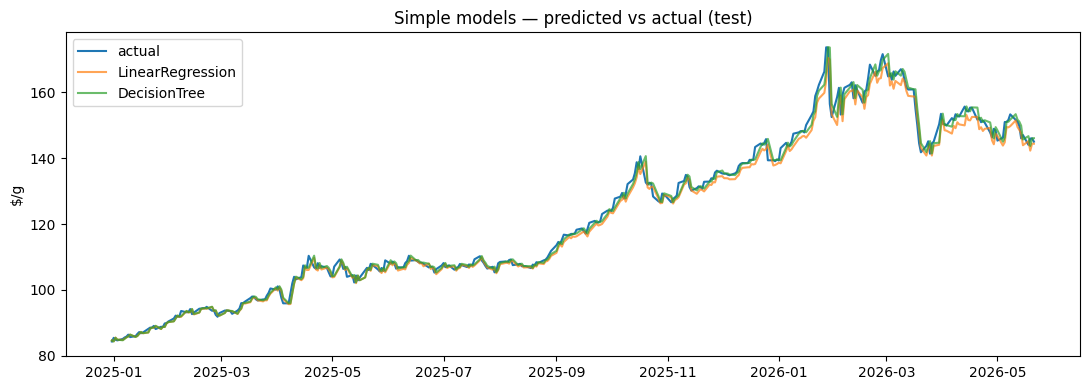

In [5]:
cmp = pd.DataFrame({"LinearRegression": lin_m, "DecisionTree": dt_m}).T
display(cmp.round(4))
plt.figure(figsize=(11, 4))
plt.plot(test["date"], actual, label="actual")
plt.plot(test["date"], lin_pred, label="LinearRegression", alpha=.7)
plt.plot(test["date"], dt_pred, label="DecisionTree", alpha=.7)
plt.title("Simple models — predicted vs actual (test)"); plt.ylabel("$/g")
plt.legend(); plt.tight_layout(); plt.show()

## Conclusion
Linear Regression (which can use the daily-varying features linearly) and the Decision Tree give a feel for how much *daily* signal the features carry. Both are scored on the same price scale as ARIMA, ready for the final comparison.